# Experiment 2: Condition vs Trust/Interaction

This notebook analyzes the relationship between condition (`baseline`, `CI`, and `2-9 lines`) and survey outcomes in Experiment 2, following the preprocessing and Cousineau+Morey within-subject normalization workflow used in `Experiment3/analysis/analysis-0318.ipynb`.

Main figures:
- Grouped bar chart across `CI`, `2 lines`, `3 lines`, `4 lines`, `5 lines`, `6 lines`, `7 lines`, `8 lines`, `9 lines` (baseline excluded) with:
  - Composite Trust score
  - Composite Interaction score
- Line chart over increasing ensemble line count (`2-9`) with CI and baseline as horizontal reference lines


In [1]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib_inline.backend_inline import set_matplotlib_formats

warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", None)

set_matplotlib_formats("svg")
plt.rcParams["savefig.format"] = "svg"

In [2]:
DATA_DIR_CANDIDATES = [
    Path("../data/0325/data"),
    Path("../data/dist 11/data"),
]
CSV_PATTERN = "user_*.csv"

CONDITION_LABELS = {
    1: "Baseline",
    2: "CI",
    3: "2 Lines",
    4: "3 Lines",
    5: "4 Lines",
    6: "5 Lines",
    7: "6 Lines",
    8: "7 Lines",
    9: "8 Lines",
    10: "9 Lines",
}

BASELINE_CONDITION_NUMBER = 1
CI_CONDITION_NUMBER = 2
TREATMENT_CONDITION_NUMBERS = [2, 3, 4, 5, 6, 7, 8, 9, 10]
ENSEMBLE_CONDITION_NUMBERS = [3, 4, 5, 6, 7, 8, 9, 10]
TREATMENT_ORDER = ["CI", "2 Lines", "3 Lines", "4 Lines", "5 Lines", "6 Lines", "7 Lines", "8 Lines", "9 Lines"]

TRUST_QUESTION_KEYS = [
    "skeptical_rating",
    "data_trust",
    "usability_difficulty",
    "comprehension_ease",
]

INTERACTION_QUESTION_KEYS = [
    "navigation_control",
    "content_control",
    "pace_control",
    "interface_exploration",
    "interface_responsiveness",
    "user_communication",
    "personal_conversation",
    "interface_interaction",
    "interface_sensitivity",
]

NORMALIZED_FLAG_COLUMN = "_cousineau_normalized"
MOREY_FACTOR_COLUMN = "_morey_factor"
K_CONDITIONS_COLUMN = "_k_conditions"


def extract_condition_number(condition_id):
    if pd.isna(condition_id):
        return np.nan
    match = re.search(r"condition_(\d+)", str(condition_id))
    return int(match.group(1)) if match else np.nan


def parse_response_json(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, dict) else {}
    except Exception:
        return {}


def expand_response_columns(data, response_col="response"):
    if response_col not in data.columns:
        return data.copy()

    parsed = data[response_col].apply(parse_response_json)
    expanded = pd.json_normalize(parsed)

    merged = data.reset_index(drop=True).copy()
    for col in expanded.columns:
        parsed_values = expanded[col]
        if col in merged.columns:
            merged[col] = merged[col].where(merged[col].notna(), parsed_values)
        else:
            merged[col] = parsed_values

    return merged


def identify_attention_check_failures(
    data,
    trust_keys=TRUST_QUESTION_KEYS,
    interaction_keys=INTERACTION_QUESTION_KEYS,
    survey_trial_type="trust-survey",
):
    if data is None or data.empty:
        return set(), pd.DataFrame()

    if "trial_type" not in data.columns or "participant_id" not in data.columns:
        return set(), pd.DataFrame()

    survey_rows = data[data["trial_type"] == survey_trial_type].copy()
    if survey_rows.empty:
        return set(), pd.DataFrame()

    survey_rows = expand_response_columns(survey_rows)
    parsed_response = (
        survey_rows["response"].apply(parse_response_json)
        if "response" in survey_rows.columns
        else pd.Series([{}] * len(survey_rows), index=survey_rows.index)
    )

    for key in trust_keys + interaction_keys:
        existing = (
            pd.to_numeric(survey_rows[key], errors="coerce")
            if key in survey_rows.columns
            else pd.Series(np.nan, index=survey_rows.index)
        )
        if existing.notna().sum() == 0:
            existing = pd.to_numeric(parsed_response.apply(lambda d: d.get(key, np.nan)), errors="coerce")
        survey_rows[key] = existing

    trust_complete = survey_rows[trust_keys].notna().all(axis=1)
    interaction_complete = survey_rows[interaction_keys].notna().all(axis=1)

    trust_uniform = survey_rows[trust_keys].nunique(axis=1, dropna=True).eq(1)
    interaction_uniform = survey_rows[interaction_keys].nunique(axis=1, dropna=True).eq(1)

    failure_mask = trust_complete & interaction_complete & trust_uniform & interaction_uniform
    failure_rows = survey_rows[failure_mask & survey_rows["participant_id"].notna()].copy()

    if failure_rows.empty:
        return set(), pd.DataFrame()

    failure_rows["participant_id"] = failure_rows["participant_id"].astype(str)
    detail_columns = [
        "participant_id",
        "condition_id",
        "condition_number",
        *trust_keys,
        *interaction_keys,
    ]
    available_detail_columns = [col for col in detail_columns if col in failure_rows.columns]
    return set(failure_rows["participant_id"].unique()), failure_rows[available_detail_columns].reset_index(drop=True)


def normalize_scores_cousineau_morey(
    data,
    metric_columns,
    baseline_condition=BASELINE_CONDITION_NUMBER,
    drop_baseline=True,
    normalization_conditions=None,
    require_complete_participants=True,
):
    if data is None or data.empty:
        normalized = pd.DataFrame() if data is None else data.copy()
        if not normalized.empty:
            normalized[NORMALIZED_FLAG_COLUMN] = False
            normalized[MOREY_FACTOR_COLUMN] = np.nan
            normalized[K_CONDITIONS_COLUMN] = np.nan
        return normalized

    required_cols = {"participant_id", "condition_number"}
    if not required_cols.issubset(data.columns):
        normalized = data.copy()
        normalized[NORMALIZED_FLAG_COLUMN] = False
        normalized[MOREY_FACTOR_COLUMN] = np.nan
        normalized[K_CONDITIONS_COLUMN] = np.nan
        return normalized

    available_columns = [col for col in metric_columns if col in data.columns]
    if not available_columns:
        normalized = data.copy()
        normalized[NORMALIZED_FLAG_COLUMN] = False
        normalized[MOREY_FACTOR_COLUMN] = np.nan
        normalized[K_CONDITIONS_COLUMN] = np.nan
        return normalized

    working = data.copy()
    working["condition_number"] = pd.to_numeric(working["condition_number"], errors="coerce")
    working[NORMALIZED_FLAG_COLUMN] = False
    working[MOREY_FACTOR_COLUMN] = np.nan
    working[K_CONDITIONS_COLUMN] = np.nan

    if normalization_conditions is None:
        observed_conditions = working["condition_number"].dropna().astype(int).unique().tolist()
        normalization_conditions = sorted(c for c in observed_conditions if c != int(baseline_condition))
    else:
        normalization_conditions = sorted({int(c) for c in normalization_conditions})

    if not normalization_conditions:
        if drop_baseline:
            working = working[working["condition_number"] != baseline_condition].copy()
        return working.reset_index(drop=True)

    normalization_mask = working["condition_number"].isin(normalization_conditions)
    normalization_data = working[normalization_mask].copy()
    if normalization_data.empty:
        if drop_baseline:
            working = working[working["condition_number"] != baseline_condition].copy()
        return working.reset_index(drop=True)

    expected_k = len(normalization_conditions)

    if require_complete_participants:
        participant_condition_counts = (
            normalization_data.groupby("participant_id", dropna=False)["condition_number"]
            .nunique()
        )
        complete_participants = participant_condition_counts[
            participant_condition_counts >= expected_k
        ].index
        normalization_data = normalization_data[
            normalization_data["participant_id"].isin(complete_participants)
        ].copy()

    if normalization_data.empty:
        if drop_baseline:
            working = working[working["condition_number"] != baseline_condition].copy()
        return working.reset_index(drop=True)

    for col in available_columns:
        numeric_values = pd.to_numeric(normalization_data[col], errors="coerce")
        participant_means = normalization_data.groupby("participant_id", dropna=False)[col].transform(
            lambda s: pd.to_numeric(s, errors="coerce").mean()
        )
        grand_mean = numeric_values.mean()
        normalized_values = numeric_values - participant_means + grand_mean
        working.loc[normalization_data.index, col] = normalized_values

    morey_factor = np.sqrt(expected_k / (expected_k - 1)) if expected_k > 1 else np.nan
    working.loc[normalization_data.index, NORMALIZED_FLAG_COLUMN] = True
    working.loc[normalization_data.index, MOREY_FACTOR_COLUMN] = morey_factor
    working.loc[normalization_data.index, K_CONDITIONS_COLUMN] = expected_k

    if drop_baseline:
        working = working[working["condition_number"] != baseline_condition].copy()

    return working.reset_index(drop=True)


def _normalize_scores_by_participant_baseline(
    data,
    metric_columns,
    baseline_condition=BASELINE_CONDITION_NUMBER,
    drop_baseline=True,
):
    return normalize_scores_cousineau_morey(
        data,
        metric_columns=metric_columns,
        baseline_condition=baseline_condition,
        drop_baseline=drop_baseline,
        normalization_conditions=TREATMENT_CONDITION_NUMBERS,
        require_complete_participants=True,
    )


def ensure_likert_columns(data, keys):
    if data.empty:
        return data.copy()

    working = data.copy()
    parsed = (
        working["response"].apply(parse_response_json)
        if "response" in working.columns
        else pd.Series([{}] * len(working), index=working.index)
    )

    for key in keys:
        existing = (
            pd.to_numeric(working[key], errors="coerce")
            if key in working.columns
            else pd.Series(np.nan, index=working.index)
        )

        if key not in working.columns or existing.notna().sum() == 0:
            extracted = pd.to_numeric(parsed.apply(lambda d: d.get(key, np.nan)), errors="coerce")
            valid = extracted.dropna()
            if not valid.empty and (valid >= 0).all() and (valid <= 6).all():
                extracted = extracted + 1
            working[key] = extracted
        else:
            working[key] = existing

    return working


def compute_composite_scores(data):
    if data is None or data.empty:
        return pd.DataFrame()

    working = data.copy()

    for col in TRUST_QUESTION_KEYS + INTERACTION_QUESTION_KEYS:
        if col in working.columns:
            working[col] = pd.to_numeric(working[col], errors="coerce")

    if {"skeptical_rating", "data_trust", "usability_difficulty", "comprehension_ease"}.issubset(working.columns):
        working["skeptical_rating_rev"] = 8 - working["skeptical_rating"]
        working["usability_difficulty_rev"] = 8 - working["usability_difficulty"]
        working["composite_trust_score"] = working[
            ["skeptical_rating_rev", "data_trust", "usability_difficulty_rev", "comprehension_ease"]
        ].mean(axis=1, skipna=True)

    interaction_available = [k for k in INTERACTION_QUESTION_KEYS if k in working.columns]
    if interaction_available:
        working["composite_interaction_score"] = working[interaction_available].mean(axis=1, skipna=True)

    return working

In [3]:
data_dir = next((p for p in DATA_DIR_CANDIDATES if p.exists()), None)
if data_dir is None:
    searched = ", ".join(str(p.resolve()) for p in DATA_DIR_CANDIDATES)
    raise FileNotFoundError(f"No Experiment 2 data directory found. Checked: {searched}")

csv_files = sorted(data_dir.glob(CSV_PATTERN))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {data_dir.resolve()} using pattern {CSV_PATTERN!r}")

all_data = []
for file_path in csv_files:
    df = pd.read_csv(file_path)
    df["source_file"] = file_path.name

    if "participant_id" not in df.columns or df["participant_id"].isna().all():
        participant_id = file_path.stem.split("_")[1]
        df["participant_id"] = participant_id

    if "condition_id" not in df.columns:
        df["condition_id"] = np.nan

    df["condition_number"] = df["condition_id"].apply(extract_condition_number)
    df["condition_label"] = df["condition_number"].map(CONDITION_LABELS).fillna("Other")

    all_data.append(df)

combined_data = pd.concat(all_data, ignore_index=True)

before_participants = combined_data["participant_id"].nunique(dropna=True)
combined_data = combined_data[combined_data["participant_id"].notna()].copy()
combined_data = combined_data[~combined_data["participant_id"].astype(str).str.lower().eq("test")].copy()

attention_failed_ids, attention_failure_rows = identify_attention_check_failures(combined_data)
if attention_failed_ids:
    combined_data = combined_data[
        ~combined_data["participant_id"].astype(str).isin(attention_failed_ids)
    ].copy()

after_participants = combined_data["participant_id"].nunique(dropna=True)

print(f"Data directory: {data_dir.resolve()}")
print(f"Found CSV files: {len(csv_files)}")
print(f"Combined shape: {combined_data.shape}")
print(f"Participants: {before_participants} -> {after_participants}")
print(f"Attention-check exclusions: {len(attention_failed_ids)}")

condition_lookup = (
    combined_data[["condition_number", "condition_id", "condition_label", "condition_name"]]
    .dropna(subset=["condition_id"])
    .drop_duplicates()
    .sort_values(["condition_number", "condition_id"])
    .reset_index(drop=True)
)

print("\nConditions present:")
display(condition_lookup)

if not attention_failure_rows.empty:
    print("\nAttention-check failures (first 10 rows):")
    display(attention_failure_rows.head(10))

Data directory: /Users/songwen/Documents/Code Lab/Interact4Trust/Experiment2/data/0325/data
Found CSV files: 91
Combined shape: (4872, 74)
Participants: 91 -> 87
Attention-check exclusions: 4

Conditions present:


,condition_number,condition_id,condition_label,condition_name
0,1.0,condition_1_baseline_aggregation,Baseline,baseline_aggregation_only_odd_hover_show_one
1,1.0,condition_1_baseline_aggregation,Baseline,baseline_aggregation_only_even_click_show_one
2,1.0,condition_1_baseline_aggregation,Baseline,baseline_aggregation_only_odd_click_show_one
3,1.0,condition_1_baseline_aggregation,Baseline,baseline_aggregation_only_even_hover_show_one
4,2.0,condition_2_ci_95,CI,ci_95_both_cities_odd_hover_show_one
5,2.0,condition_2_ci_95,CI,ci_95_both_cities_even_click_show_one
6,2.0,condition_2_ci_95,CI,ci_95_both_cities_odd_click_show_one
7,2.0,condition_2_ci_95,CI,ci_95_both_cities_even_hover_show_one
8,3.0,condition_3_ensemble_2_lines,2 Lines,ensemble_2_lines_per_city_odd_hover_show_one
9,3.0,condition_3_ensemble_2_lines,2 Lines,ensemble_2_lines_per_city_even_click_show_one



Attention-check failures (first 10 rows):


,participant_id,condition_id,condition_number,skeptical_rating,data_trust,usability_difficulty,comprehension_ease,navigation_control,content_control,pace_control,interface_exploration,interface_responsiveness,user_communication,personal_conversation,interface_interaction,interface_sensitivity
0,66293da691cec8862619b1dc,condition_4_ensemble_3_lines,4.0,4.0,4.0,4.0,4.0,3,3,3,3,3,3,3,3,3
1,672a2783cde978a12841f230,condition_9_ensemble_8_lines,9.0,4.0,4.0,4.0,4.0,0,0,0,0,0,0,0,0,0
2,69b6ca3f88fee21c0704ae64,condition_6_ensemble_5_lines,6.0,4.0,4.0,4.0,4.0,3,3,3,3,3,3,3,3,3
3,69b6ca3f88fee21c0704ae64,condition_8_ensemble_7_lines,8.0,4.0,4.0,4.0,4.0,3,3,3,3,3,3,3,3,3
4,6994a3207108947586c5f99c,condition_2_ci_95,2.0,4.0,4.0,4.0,4.0,3,3,3,3,3,3,3,3,3


In [4]:
trust_survey_rows = combined_data[combined_data["trial_type"] == "trust-survey"].copy()
trust_survey_expanded = ensure_likert_columns(
    trust_survey_rows,
    TRUST_QUESTION_KEYS + INTERACTION_QUESTION_KEYS,
)

analysis_metric_columns = [
    col for col in (TRUST_QUESTION_KEYS + INTERACTION_QUESTION_KEYS)
    if col in trust_survey_expanded.columns
]

analysis_trust_survey_expanded = _normalize_scores_by_participant_baseline(
    trust_survey_expanded,
    metric_columns=analysis_metric_columns,
    baseline_condition=BASELINE_CONDITION_NUMBER,
    drop_baseline=False,
)

analysis_treatment_survey = analysis_trust_survey_expanded[
    analysis_trust_survey_expanded["condition_number"].isin(TREATMENT_CONDITION_NUMBERS)
    & analysis_trust_survey_expanded[NORMALIZED_FLAG_COLUMN].fillna(False)
].copy()

print(f"Trust-survey rows: {len(trust_survey_rows)}")
print(f"Rows with parsed Likert columns: {len(trust_survey_expanded)}")
print(f"Normalized treatment rows kept: {len(analysis_treatment_survey)}")
print(f"Participants retained after complete-condition requirement: {analysis_treatment_survey['participant_id'].nunique()}")

Trust-survey rows: 870
Rows with parsed Likert columns: 870
Normalized treatment rows kept: 783
Participants retained after complete-condition requirement: 87


In [5]:
composite_treatment = compute_composite_scores(analysis_treatment_survey)
composite_treatment["condition_label"] = composite_treatment["condition_number"].map(CONDITION_LABELS)

condition_level_summary = (
    composite_treatment[
        composite_treatment["condition_number"].isin(TREATMENT_CONDITION_NUMBERS)
        & composite_treatment["composite_trust_score"].notna()
        & composite_treatment["composite_interaction_score"].notna()
    ]
    .groupby(["condition_number", "condition_label"], as_index=False)
    .agg(
        trust_mean=("composite_trust_score", "mean"),
        trust_sd=("composite_trust_score", "std"),
        interaction_mean=("composite_interaction_score", "mean"),
        interaction_sd=("composite_interaction_score", "std"),
        n=("participant_id", "count"),
    )
)

available_morey = pd.to_numeric(composite_treatment.get(MOREY_FACTOR_COLUMN), errors="coerce").dropna()
morey_factor = float(available_morey.iloc[0]) if not available_morey.empty else np.nan
if pd.notna(morey_factor):
    condition_level_summary["trust_sd"] = condition_level_summary["trust_sd"] * morey_factor
    condition_level_summary["interaction_sd"] = condition_level_summary["interaction_sd"] * morey_factor

condition_level_summary["trust_se"] = condition_level_summary["trust_sd"] / np.sqrt(condition_level_summary["n"].clip(lower=1))
condition_level_summary["interaction_se"] = condition_level_summary["interaction_sd"] / np.sqrt(condition_level_summary["n"].clip(lower=1))

condition_level_summary["condition_label"] = pd.Categorical(
    condition_level_summary["condition_label"],
    categories=TREATMENT_ORDER,
    ordered=True,
)
condition_level_summary = condition_level_summary.sort_values("condition_label").reset_index(drop=True)

print("Condition-level Cousineau-normalized composite means (Morey-corrected SE):")
display(condition_level_summary.round(3))
print(f"Morey factor: {morey_factor:.4f}" if pd.notna(morey_factor) else "Morey factor: NA")

Condition-level Cousineau-normalized composite means (Morey-corrected SE):


,condition_number,condition_label,trust_mean,trust_sd,interaction_mean,interaction_sd,n,trust_se,interaction_se
0,2.0,CI,5.241,0.912,3.794,0.560,87,0.098,0.060
1,3.0,2 Lines,5.109,0.782,3.839,0.378,87,0.084,0.041
2,4.0,3 Lines,5.158,0.653,3.817,0.390,87,0.070,0.042
3,5.0,4 Lines,4.948,0.693,3.779,0.375,87,0.074,0.040
4,6.0,5 Lines,4.908,0.683,3.778,0.397,87,0.073,0.043
5,7.0,6 Lines,5.207,0.565,3.872,0.343,87,0.061,0.037
6,8.0,7 Lines,5.092,0.678,3.837,0.377,87,0.073,0.040
7,9.0,8 Lines,4.980,0.679,3.770,0.265,87,0.073,0.028
8,10.0,9 Lines,5.092,0.733,3.757,0.468,87,0.079,0.050


Morey factor: 1.0607


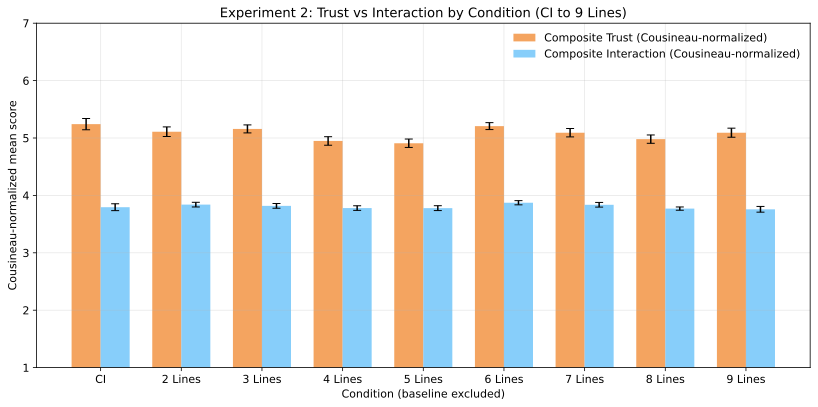

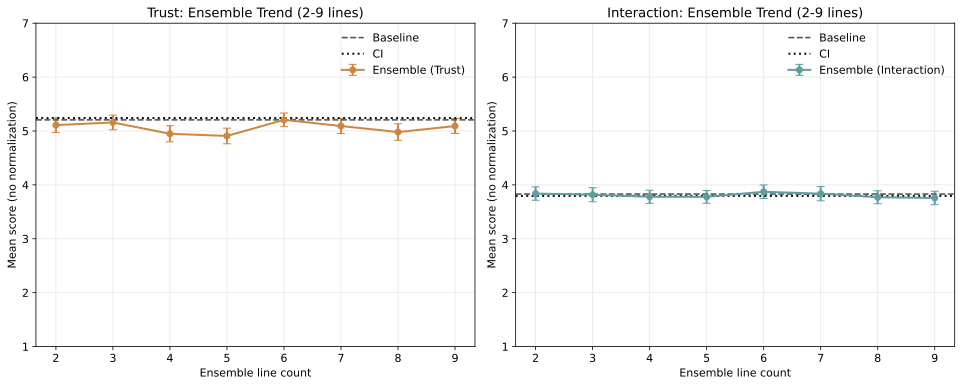

In [6]:
plot_df = condition_level_summary.copy()

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(11.5, 5.8))
ax.bar(
    x - width / 2,
    plot_df["trust_mean"],
    width,
    yerr=plot_df["trust_se"],
    capsize=4,
    label="Composite Trust (Cousineau-normalized)",
    color="#F4A460",
)
ax.bar(
    x + width / 2,
    plot_df["interaction_mean"],
    width,
    yerr=plot_df["interaction_se"],
    capsize=4,
    label="Composite Interaction (Cousineau-normalized)",
    color="#87CEFA",
)

ax.set_ylim(1, 7)
ax.set_yticks(np.arange(1, 8))
ax.set_xticks(x)
ax.set_xticklabels(plot_df["condition_label"].astype(str).tolist())
ax.set_xlabel("Condition (baseline excluded)")
ax.set_ylabel("Cousineau-normalized mean score")
ax.set_title("Experiment 2: Trust vs Interaction by Condition (CI to 9 Lines)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

raw_composite = compute_composite_scores(trust_survey_expanded.copy())
raw_composite = raw_composite[
    raw_composite["condition_number"].isin([BASELINE_CONDITION_NUMBER, *TREATMENT_CONDITION_NUMBERS])
    & raw_composite["composite_trust_score"].notna()
    & raw_composite["composite_interaction_score"].notna()
].copy()

raw_composite["condition_label"] = raw_composite["condition_number"].map(CONDITION_LABELS)
raw_condition_order = ["Baseline", *TREATMENT_ORDER]

raw_condition_summary = (
    raw_composite.groupby(["condition_number", "condition_label"], as_index=False)
    .agg(
        trust_mean=("composite_trust_score", "mean"),
        trust_sd=("composite_trust_score", "std"),
        interaction_mean=("composite_interaction_score", "mean"),
        interaction_sd=("composite_interaction_score", "std"),
        n=("participant_id", "count"),
    )
)

raw_condition_summary["trust_se"] = raw_condition_summary["trust_sd"] / np.sqrt(raw_condition_summary["n"].clip(lower=1))
raw_condition_summary["interaction_se"] = raw_condition_summary["interaction_sd"] / np.sqrt(raw_condition_summary["n"].clip(lower=1))

raw_condition_summary["condition_label"] = pd.Categorical(
    raw_condition_summary["condition_label"],
    categories=raw_condition_order,
    ordered=True,
)
raw_plot_df = raw_condition_summary.sort_values("condition_label").reset_index(drop=True)

baseline_row = raw_plot_df[raw_plot_df["condition_number"] == BASELINE_CONDITION_NUMBER]
ci_row = raw_plot_df[raw_plot_df["condition_number"] == CI_CONDITION_NUMBER]
ensemble_plot_df = raw_plot_df[raw_plot_df["condition_number"].isin(ENSEMBLE_CONDITION_NUMBERS)].copy()
ensemble_plot_df["line_count"] = ensemble_plot_df["condition_number"] - 1

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5), sharex=True)

metric_specs = [
    ("trust_mean", "trust_se", "Trust", "#CD853F"),
    ("interaction_mean", "interaction_se", "Interaction", "#5F9EA0"),
]

for ax, (mean_col, se_col, label, color) in zip(axes, metric_specs):
    ax.errorbar(
        ensemble_plot_df["line_count"],
        ensemble_plot_df[mean_col],
        yerr=ensemble_plot_df[se_col],
        color=color,
        marker="o",
        linewidth=2,
        capsize=4,
        label=f"Ensemble ({label})",
    )

    if not baseline_row.empty:
        ax.axhline(
            float(baseline_row.iloc[0][mean_col]),
            color="#555555",
            linestyle="--",
            linewidth=1.6,
            label="Baseline",
        )

    if not ci_row.empty:
        ax.axhline(
            float(ci_row.iloc[0][mean_col]),
            color="#111111",
            linestyle=":",
            linewidth=2,
            label="CI",
        )

    if not ensemble_plot_df.empty:
        xticks = sorted(ensemble_plot_df["line_count"].astype(int).unique().tolist())
        ax.set_xticks(xticks)

    ax.set_ylim(1, 7)
    ax.set_yticks(np.arange(1, 8))
    ax.set_xlabel("Ensemble line count")
    ax.set_ylabel("Mean score (no normalization)")
    ax.set_title(f"{label}: Ensemble Trend (2-9 lines)")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [7]:
# Optional export of summary table
output_path = Path("./experiment2_condition_trust_interaction_summary_0325.csv")
condition_level_summary.round(4).to_csv(output_path, index=False)
print(f"Saved summary table to: {output_path.resolve()}")

Saved summary table to: /Users/songwen/Documents/Code Lab/Interact4Trust/Experiment2/analysis/experiment2_condition_trust_interaction_summary_0325.csv
